<a href="https://colab.research.google.com/github/rickiepark/deep-learning-with-python-3rd/blob/main/chapter03_introduction-to-ml-frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

이 노트북은 <[케라스 창시자에게 배우는 딥러닝 (개정 3판)](https://tensorflow.blog/kerasdl3/)>(길벗, 2026)의 예제 코드를 담고 있습니다.

In [1]:
!pip install keras keras-hub --upgrade -q

In [2]:
import keras, keras_hub

print(keras.__version__)
print(keras_hub.__version__)

3.15.1
0.31.0


In [3]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"이 셀은 {required} 백엔드가 필요합니다. 실행을 위해 노트북 서두에서 KERAS_BACKEND를 "
            f"\"{required}\"로 바꾸고 런타임을 재식한 다음 노트북을 다시 실행하세요."
        )

## 텐서플로, 파이토치, JAX 그리고 케라스에 대한 소개

### 딥러닝 프레임워크의 간략한 역사

### 프레임워크 사이의 관계

### 텐서플로 소개

#### 텐서플로 첫걸음

##### 텐서플로의 텐서와 변수

###### 상수 텐서

In [5]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [6]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [7]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### 랜덤 텐서

In [8]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[0.80000985]
 [1.1384625 ]
 [1.073755  ]], shape=(3, 1), dtype=float32)


In [9]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.609992  ]
 [0.8791938 ]
 [0.90858364]], shape=(3, 1), dtype=float32)


###### 텐서 할당과 Variable 클래스

In [10]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [11]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[0.36587006],
       [0.7878905 ],
       [1.6293604 ]], dtype=float32)>


In [12]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [13]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [14]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

##### 텐서 연산: 텐서플로로 수학 계산하기

In [15]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)

In [16]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### 텐서플로의 그레이디언트: GradientTape API 다시 살펴 보기

In [17]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

In [18]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [19]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

##### 컴파일을 사용해 텐서플로 함수 속도 높이기

In [20]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [21]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### 엔드-투-엔드 예제: 순수 텐서플로로 구현하는 선형 분류기

In [22]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [23]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [24]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

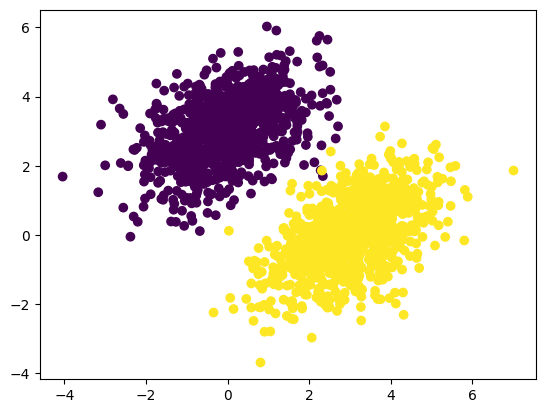

In [25]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [26]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [27]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [28]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [29]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [30]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"{step}번째 스텝의 손실: {loss:.4f}")

0번째 스텝의 손실: 2.9065
1번째 스텝의 손실: 0.4901
2번째 스텝의 손실: 0.1769
3번째 스텝의 손실: 0.1280
4번째 스텝의 손실: 0.1146
5번째 스텝의 손실: 0.1064
6번째 스텝의 손실: 0.0995
7번째 스텝의 손실: 0.0932
8번째 스텝의 손실: 0.0874
9번째 스텝의 손실: 0.0822
10번째 스텝의 손실: 0.0773
11번째 스텝의 손실: 0.0729
12번째 스텝의 손실: 0.0688
13번째 스텝의 손실: 0.0651
14번째 스텝의 손실: 0.0617
15번째 스텝의 손실: 0.0586
16번째 스텝의 손실: 0.0557
17번째 스텝의 손실: 0.0531
18번째 스텝의 손실: 0.0507
19번째 스텝의 손실: 0.0485
20번째 스텝의 손실: 0.0465
21번째 스텝의 손실: 0.0446
22번째 스텝의 손실: 0.0429
23번째 스텝의 손실: 0.0414
24번째 스텝의 손실: 0.0400
25번째 스텝의 손실: 0.0387
26번째 스텝의 손실: 0.0375
27번째 스텝의 손실: 0.0364
28번째 스텝의 손실: 0.0354
29번째 스텝의 손실: 0.0345
30번째 스텝의 손실: 0.0336
31번째 스텝의 손실: 0.0329
32번째 스텝의 손실: 0.0322
33번째 스텝의 손실: 0.0315
34번째 스텝의 손실: 0.0309
35번째 스텝의 손실: 0.0304
36번째 스텝의 손실: 0.0299
37번째 스텝의 손실: 0.0294
38번째 스텝의 손실: 0.0290
39번째 스텝의 손실: 0.0286


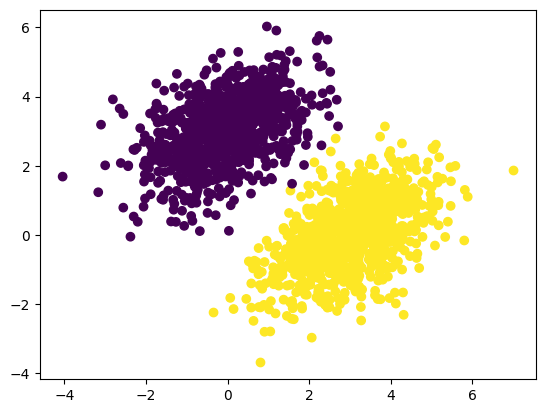

In [31]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

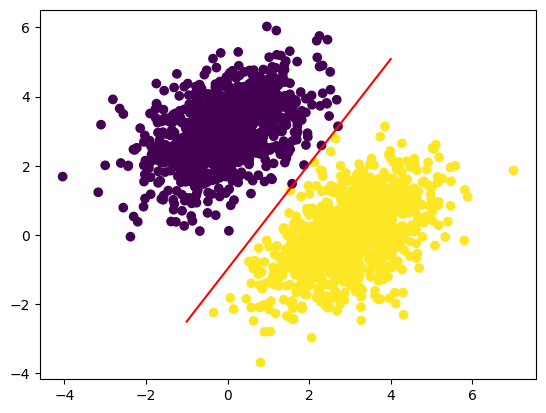

In [32]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

#### 텐서플로 방식의 차이점

### 파이토치 소개

#### 파이토치 첫걸음

##### 파이토치 텐서와 파라미터

###### 상수 텐서

In [33]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

In [34]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [35]:
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

###### 랜덤 텐서

In [36]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))

tensor([[ 0.0276],
        [-0.9979],
        [-0.8182]])

In [37]:
torch.rand(3, 1)

tensor([[0.0265],
        [0.5692],
        [0.5229]])

###### 텐서 할당과 Parameter 클래스

In [38]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

In [39]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### 텐서 연산: 파이토치로 수학 계산하기

In [40]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

In [41]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### 파이토치로 그레이디언트 계산하기

In [42]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

In [43]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(12.)

In [44]:
input_var.grad = None

#### 엔드-투-엔드 예제: 순수 파이토치로 구현하는 선형 분류기

In [45]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [46]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [47]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [48]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

##### Module 클래스로 상태과 계산 패키징하기

In [49]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [50]:
model = LinearModel()

In [51]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [52]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [53]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

##### 컴파일을 사용해 파이토치 모듈 속도 높이기

In [54]:
compiled_model = torch.compile(model)

In [55]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

#### 파이토치 방식의 차이점

### JAX 소개

#### JAX 첫걸음

#### JAX의 텐서

In [56]:
from jax import numpy as jnp
jnp.ones(shape=(2, 1))

Array([[1.],
       [1.]], dtype=float32)

In [57]:
jnp.zeros(shape=(2, 1))

Array([[0.],
       [0.]], dtype=float32)

In [58]:
jnp.array([1, 2, 3], dtype="float32")

Array([1., 2., 3.], dtype=float32)

#### JAX의 난수 생성

In [59]:
np.random.normal(size=(3,))

array([ 0.06050951,  0.73791298, -1.62559954])

In [60]:
np.random.normal(size=(3,))

array([-0.87316435, -0.48025324,  1.26602874])

In [61]:
def apply_noise(x, seed):
    np.random.seed(seed)
    x = x * np.random.normal((3,))
    return x

seed = 1337
y = apply_noise(x, seed)
seed += 1
z = apply_noise(x, seed)

/tmp/ipykernel_2604/2654806653.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x = x * np.random.normal((3,))


In [62]:
import jax

seed_key = jax.random.key(1337)

In [63]:
seed_key = jax.random.key(0)
jax.random.normal(seed_key, shape=(3,))

Array([ 1.6226422 ,  2.0252647 , -0.43359444], dtype=float32)

In [64]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [65]:
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [66]:
seed_key = jax.random.key(123)
jax.random.normal(seed_key, shape=(3,))

Array([1.6359469 , 0.8408094 , 0.02212393], dtype=float32)

In [67]:
new_seed_key = jax.random.split(seed_key, num=1)[0]
jax.random.normal(new_seed_key, shape=(3,))

Array([-0.49093357, -0.9478693 , -1.775197  ], dtype=float32)

##### 텐서 할당

In [68]:
x = jnp.array([1, 2, 3], dtype="float32")
new_x = x.at[0].set(10)

##### 텐서 연산: JAX로 수학 계산하기

In [69]:
a = jnp.ones((2, 2))
b = jnp.square(a)
c = jnp.sqrt(a)
d = b + c
e = jnp.matmul(a, b)
e *= d

In [70]:
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

##### JAX로 그레이디언트 계산하기

In [71]:
def compute_loss(input_var):
    return jnp.square(input_var)

In [72]:
grad_fn = jax.grad(compute_loss)

In [73]:
input_var = jnp.array(3.0)
grad_of_loss_wrt_input_var = grad_fn(input_var)

##### JAX 그레이디언트 계산의 모범 사례

###### 손실 값 반환

In [74]:
grad_fn = jax.value_and_grad(compute_loss)
output, grad_of_loss_wrt_input_var = grad_fn(input_var)

###### 복잡한 함수에 대한 그레이디언트 구하기

###### 보조 출력 반환

##### @jax.jit로 JAX 함수 속도 높이기

In [75]:
@jax.jit
def dense(inputs, W, b):
    return jax.nn.relu(jnp.matmul(inputs, W) + b)

#### 엔드-투-엔드 예제: 순수 JAX로 구현하는 선형 분류기

In [76]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b

def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [77]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)
    return loss

In [78]:
grad_fn = jax.value_and_grad(compute_loss)

In [79]:
learning_rate = 0.1

@jax.jit
def training_step(inputs, targets, W, b):
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate
    return loss, W, b

In [80]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)
for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"{step}번째 스텝의 손실: {loss:.4f}")

0번째 스텝의 손실: 3.5902
1번째 스텝의 손실: 0.2430
2번째 스텝의 손실: 0.1220
3번째 스텝의 손실: 0.1006
4번째 스텝의 손실: 0.0924
5번째 스텝의 손실: 0.0865
6번째 스텝의 손실: 0.0813
7번째 스텝의 손실: 0.0765
8번째 스텝의 손실: 0.0722
9번째 스텝의 손실: 0.0682
10번째 스텝의 손실: 0.0645
11번째 스텝의 손실: 0.0611
12번째 스텝의 손실: 0.0581
13번째 스텝의 손실: 0.0552
14번째 스텝의 손실: 0.0527
15번째 스텝의 손실: 0.0503
16번째 스텝의 손실: 0.0481
17번째 스텝의 손실: 0.0462
18번째 스텝의 손실: 0.0443
19번째 스텝의 손실: 0.0427
20번째 스텝의 손실: 0.0411
21번째 스텝의 손실: 0.0397
22번째 스텝의 손실: 0.0385
23번째 스텝의 손실: 0.0373
24번째 스텝의 손실: 0.0362
25번째 스텝의 손실: 0.0352
26번째 스텝의 손실: 0.0343
27번째 스텝의 손실: 0.0335
28번째 스텝의 손실: 0.0327
29번째 스텝의 손실: 0.0320
30번째 스텝의 손실: 0.0314
31번째 스텝의 손실: 0.0308
32번째 스텝의 손실: 0.0303
33번째 스텝의 손실: 0.0298
34번째 스텝의 손실: 0.0293
35번째 스텝의 손실: 0.0289
36번째 스텝의 손실: 0.0286
37번째 스텝의 손실: 0.0282
38번째 스텝의 손실: 0.0279
39번째 스텝의 손실: 0.0276


#### JAX 방식의 차이점

### 케라스 소개

#### 케라스 첫걸음

##### 백엔드 프레임워크 선택하기

In [81]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras

#### 층: 딥러닝의 구성 요소

##### 케라스의 `Layer` 클래스

In [82]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

In [83]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


##### 자동 크기 추론: 동적으로 층 만들기

In [84]:
from keras import layers

layer = layers.Dense(32, activation="relu")

In [85]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

In [86]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

#### 층에서 모듈로

#### "컴파일" 단계: 학습 과정 설정

In [87]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

In [88]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

#### 손실 함수 선택하기

#### fit 메서드 이해하기

In [89]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.6965 - loss: 8.3388
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7100 - loss: 7.9527 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7260 - loss: 7.6265 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.7380 - loss: 7.3167 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7490 - loss: 7.0207 


In [90]:
history.history

{'binary_accuracy': [0.6965000033378601,
  0.7099999785423279,
  0.7260000109672546,
  0.7379999756813049,
  0.7490000128746033],
 'loss': [8.338773727416992,
  7.952663898468018,
  7.626465797424316,
  7.316667079925537,
  7.020653247833252]}

#### 검증 데이터에서 손실과 평가 지표 모니터링하기

In [91]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.9664 - loss: 0.2191 - val_binary_accuracy: 0.9467 - val_loss: 0.0938
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9529 - loss: 0.0716 - val_binary_accuracy: 0.7600 - val_loss: 0.1479
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.9543 - loss: 0.0713 - val_binary_accuracy: 0.9933 - val_loss: 0.0455
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9664 - loss: 0.0684 - val_binary_accuracy: 0.9983 - val_loss: 0.0311
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.9557 - loss: 0.0757 - val_binary_accuracy: 0.9983 - val_loss: 0.0525


#### 추론: 훈련한 모델 사용하기

In [92]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.22189733]
 [0.77687657]
 [0.88318735]
 [0.74771476]
 [0.43717024]
 [0.7086789 ]
 [0.76882577]
 [0.2786746 ]
 [0.125501  ]
 [0.14499533]]
